In [2]:
import pandas as pd

In [ ]:
#loading data into dataframe
df = pd.read_csv('../data/music_data.csv')

In [4]:
#checking for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

In [5]:
#visualizing data
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
#libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

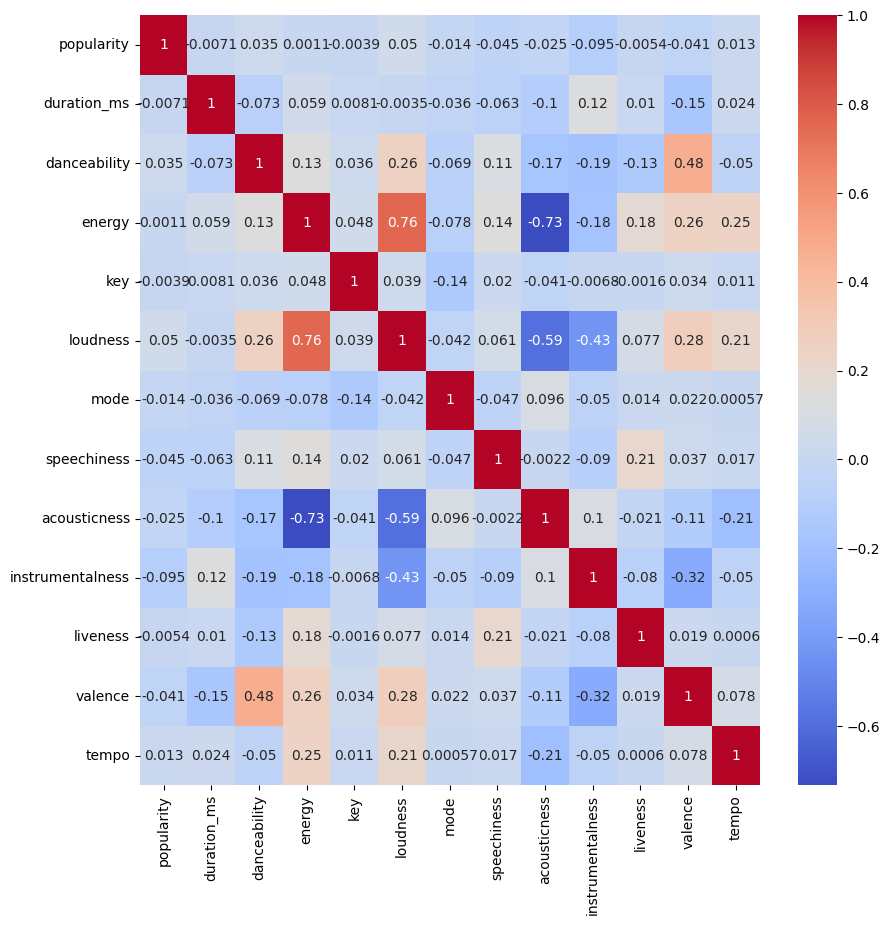

In [7]:
#picking all features with numerical values
features = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

#graphing heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')

In [8]:
#picking features with high correlations
features_picked = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 'valence']

#columns needed for dropping na's
columns_needed = features_picked + ['track_name', 'artists']

In [9]:
#dropping rows based on whether they have na's
df_dropped = df.dropna(subset=columns_needed).copy()
df_dropped.info()

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      113999 non-null  int64  
 1   Unnamed: 0        113999 non-null  int64  
 2   track_id          113999 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        113999 non-null  int64  
 7   duration_ms       113999 non-null  int64  
 8   explicit          113999 non-null  bool   
 9   danceability      113999 non-null  float64
 10  energy            113999 non-null  float64
 11  key               113999 non-null  int64  
 12  loudness          113999 non-null  float64
 13  mode              113999 non-null  int64  
 14  speechiness       113999 non-null  float64
 15  acousticness      113999 non-null  float64
 16  instrumentalness  113999 non-null  f

In [ ]:
#importing and defining scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
#scalling featues 
scaled_features = scaler.fit_transform(df_dropped[features_picked])

#creating a new dataframe with scaled features
df_scaled = pd.DataFrame(scaled_features, columns=features_picked)
df_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,tempo,valence
0,0.629239,-0.717147,0.300825,0.551843,-0.850193,-0.504111,-1.141854,0.929315
1,-0.845908,-1.889974,-1.784739,-0.078995,1.831744,-0.504097,-1.489708,-0.798681
2,-0.742187,-1.122667,-0.293289,-0.273827,-0.315489,-0.504115,-1.528303,-1.365679
3,-1.733301,-2.312987,-2.039246,-0.457309,1.774605,-0.503886,1.987857,-1.276965
4,0.295026,-0.788709,-0.282751,-0.303146,0.463409,-0.504115,-0.073343,-1.184394


In [ ]:
#adding the track_name and artists collumns back to the scaled dataframe
df_scaled = df_scaled.join(df_dropped[['track_name', 'artists']])

In [ ]:
#making the track_name and artists lower cased to make them easier to check later
df_scaled['track_name'] = df_scaled['track_name'].str.lower()
df_scaled['artists'] = df_scaled['artists'].str.lower()

In [ ]:
#saving the scaled data frame to a csv file
df_scaled.to_csv('../data/cleaned_music_data.csv', index=False)

In [ ]:
#visualizing data to make sure it is accurage
df_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,tempo,valence,track_name,artists
0,0.629239,-0.717147,0.300825,0.551843,-0.850193,-0.504111,-1.141854,0.929315,comedy,gen hoshino
1,-0.845908,-1.889974,-1.784739,-0.078995,1.831744,-0.504097,-1.489708,-0.798681,ghost - acoustic,ben woodward
2,-0.742187,-1.122667,-0.293289,-0.273827,-0.315489,-0.504115,-1.528303,-1.365679,to begin again,ingrid michaelson;zayn
3,-1.733301,-2.312987,-2.039246,-0.457309,1.774605,-0.503886,1.987857,-1.276965,can't help falling in love,kina grannis
4,0.295026,-0.788709,-0.282751,-0.303146,0.463409,-0.504115,-0.073343,-1.184394,hold on,chord overstreet
